## This is the code to Analyze the Neighbour Influence 2 Experiment

By default, if you play this file directly, it will generate the Rank-Position distribution plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists and label lists -> Merge the score with cluster group and then sort them on score -> Plot the rank distribution of the list. Represent each cluster group inside the plot.

**Format**:  
**Input** The Influence lists and label lists that you read in.  
**Output**  The Rank-Position distribution Plot 

You don't need to change anything else if you only want to produce the Heatmap plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [3]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns
from scipy import stats

1. Read in the influence and label data

In [4]:
IF_1 = pd.read_csv("SmallLargeDensity/IF_LargeSmall_Density_sep3_var41.csv")

TC_1 = pd.read_csv("SmallLargeDensity/TC_LargeSmall_Density_sep3_var41.csv")

Label_1 = pd.read_csv("SmallLargeDensity/Large_Small_Density_sep3_labelIDs_var41.csv")


In [5]:
IF_2 = pd.read_csv("SmallLargeDensity/IF_LargeSmall_Density_sep3.csv")

TC_2 = pd.read_csv("SmallLargeDensity/TC_LargeSmall_Density_sep3.csv")

Label_2 = pd.read_csv("SmallLargeDensity/Large_Small_Density_sep3_labelIDs.csv")


In [6]:
# IF_1["Score"] = IF_1["Score"].abs()
# IF_2["Score"] = IF_2["Score"].abs()

In [7]:
# IF_1 = IF_1.sort_values(by="Score", ascending=False).reset_index(drop=True)
# IF_2 = IF_2.sort_values(by="Score", ascending=False).reset_index(drop=True)

In [8]:
print(IF_1)

      Train_ID     Score
0         5980  0.047511
1          138  0.039885
2         5164  0.035171
3          353  0.034331
4         3435  0.032639
...        ...       ...
7495      7733 -0.427789
7496        30 -0.433397
7497      5309 -0.433943
7498      4815 -0.508070
7499      3588 -0.710342

[7500 rows x 2 columns]


2. Then we merge the influence score with the label, cluster Id

In [9]:
ranked_1 = (IF_1.merge(Label_1,left_on="Train_ID", right_on="id", how="left"))
ranked_1 = ranked_1.drop(columns = ["id"])
print(ranked_1)

      Train_ID     Score  label cluster_id
0         5980  0.047511      1   1_sparse
1          138  0.039885      1   1_sparse
2         5164  0.035171      1   1_sparse
3          353  0.034331      1   1_sparse
4         3435  0.032639      1   1_sparse
...        ...       ...    ...        ...
7495      7733 -0.427789      0          0
7496        30 -0.433397      0          0
7497      5309 -0.433943      0          0
7498      4815 -0.508070      0          0
7499      3588 -0.710342      0          0

[7500 rows x 4 columns]


In [10]:
ranked_2 = (IF_2.merge(Label_2,left_on="Train_ID", right_on="id", how="left"))
ranked_2 = ranked_2.drop(columns = ["id"])
print(ranked_2)

      Train_ID     Score  label cluster_id
0         2349  0.097611      1   1_sparse
1         6618  0.074400      0          0
2         2396  0.065936      1   1_sparse
3         7046  0.065794      1   1_sparse
4         4721  0.060628      1   1_sparse
...        ...       ...    ...        ...
7495      1526 -0.424637      1   1_sparse
7496      1081 -0.430545      1   1_sparse
7497      7204 -0.595458      1   1_sparse
7498      3955 -0.647208      1   1_sparse
7499       926 -0.677549      0          0

[7500 rows x 4 columns]


3. Next we could then check the influence of each cluster group. 1_sparse represent influence distribution of sparse group. 1_dense represent influence distribution of dense group. **Here in the plot, a smaller x-axis means a higher rank they achieve. Vice versa.** Since the influence also includes the negative influences. Both sides of the x-axis will mean a higher influence value, only with a different sign. In the sample plot, we see that 1_sparse continuously achieve larger influence, while 1_dense achieving smaller influence.

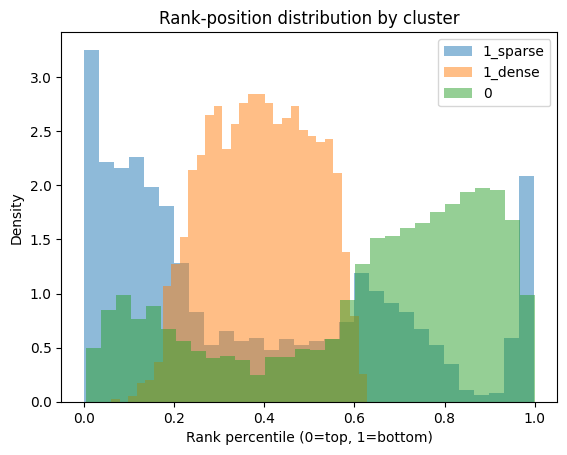

In [11]:
df = ranked_1.copy()
df['rank'] = df['Score'].rank(ascending=False, method='average')
n = len(df)
df['rank_pct'] = df['rank'] / (n + 1) 

fig, ax = plt.subplots()

for cid in ['1_sparse','1_dense','0']:
    x = df.loc[df['cluster_id']==cid, 'rank_pct']
    ax.hist(x, bins=30, alpha=0.5, label=cid, density=True)

ax.set_xlabel('Rank percentile (0=top, 1=bottom)')
ax.set_ylabel('Density')
ax.set_title('Rank-position distribution by cluster')
ax.legend()
plt.show()

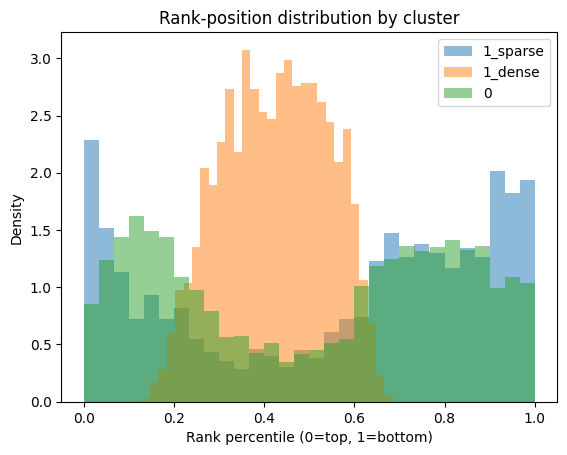

In [12]:
df = ranked_2.copy()
df['rank'] = df['Score'].rank(ascending=False, method='average')
n = len(df)
df['rank_pct'] = df['rank'] / (n + 1) 

fig, ax = plt.subplots()

for cid in ['1_sparse','1_dense','0']:
    x = df.loc[df['cluster_id']==cid, 'rank_pct']
    ax.hist(x, bins=30, alpha=0.5, label=cid, density=True)

ax.set_xlabel('Rank percentile (0=top, 1=bottom)')
ax.set_ylabel('Density')
ax.set_title('Rank-position distribution by cluster')
ax.legend()
plt.show()